In [1]:
import numpy as np
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.ticker import MaxNLocator


# Function definitions

In [2]:
def Hubble(Hkin, z, fStar):
    """
    Returns de Hubble parameter at the time z

    :param Hkin: Hubble parameter at the onset of kination
    :param z: Time, in program units, at which we want to cumpute the Hubble parameter
    :param fStar: Rescaling program variable
    """
    return Hkin / (1.0 + 3.0 * Hkin * z / fStar)


def Hubble_conf(z, nu):
    """
    Returns de conformal Hubble parameter at the time z

    :param z: Time, in program units, at which we want to cumpute the Hubble parameter
    :param nu: associated to the coupling to curvature by xi=(2/3)nu^2
    """
    return 1 / (2*(z+nu))

def escale_factor(z,nu):
    """
    Returns de scale factor at the time z

    :param Hkin: Hubble parameter at the onset of kination
    :param z: Time, in program units, at which we want to cumpute the scale factor
    :param fStar: Rescaling program variable
    """
    return np.sqrt(1+z/nu)


In [3]:
def potential(h,Hkin,H, nu, hoL, g, mtop ):
   """
   Returns the potential at the field value h

   :param h: field value at which we want to compute the potential
   :param Hkin: Hubble parameter at the onset of kination
   :param H: Hubble parameter at the time we want to compute the potential
   :param nu: associated to the coupling to curvature by xi=(2/3)nu^2
   :param hoL: cutoff scale for the sixth order term
   :param g: sixth order coupling
   :param mtop: top quark pole mass
   """
   Xi = nu*nu * 2 / 3
   fStar = np.sqrt(6 * Xi) * Hkin

   #Coefficients for the running of the quartic self-coupling
   lzero = 7.319652247935477 - 0.09134280450017569*mtop + 0.00029435490652276694*mtop*mtop
   c1 = 0.19832934168591682 - 0.0023418078957534593*mtop + 7.0529784991027215*1e-6*mtop*mtop
   c2 = -0.00014834997676202406 + 7.880425366892111*1e-7*mtop
   c3 = -4.199672393249224 + 0.05306790221079956*mtop - 0.00017089598924459676*mtop*mtop

   #Rescaling to program variables
   H_prog=H/fStar
   h_prog=h/fStar

   #Potential terms
   V2=-3.0 * (h_prog)**2 * Xi * (H_prog)**2
   V4=(lzero + c1*(np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0 +c2*( (np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0)**2+ c3*np.log((np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0))*(h_prog**4)/4
   V6=g**2*(h_prog**6)*(fStar**2)/(8*(hoL)**2)

   return fStar**4*(V2+V4+V6)

def lamb(h,mtop,H,nu,Hkin):
    """
    Returns de value of the running of the quartic self-coupling lambda at field value h

    :param h: Field value at which we want to compute the quartic self-coupling
    :param mtop: top quark pole mass
    :param H: Hubble parameter for which we want to compute the quartic self-coupling
    :param nu: associated to the coupling to curvature by xi=(2/3)nu^2
    :param Hkin: Hubble parameter at the onset of kination
    """

    Xi = nu*nu * 2 / 3
    fStar = np.sqrt(6 * Xi) * Hkin

    #Coefficients
    lzero = 7.319652247935477 - 0.09134280450017569*mtop + 0.00029435490652276694*mtop*mtop
    c1 = 0.19832934168591682 - 0.0023418078957534593*mtop + 7.0529784991027215*1e-6*mtop*mtop
    c2 = -0.00014834997676202406 + 7.880425366892111*1e-7*mtop
    c3 = -4.199672393249224 + 0.05306790221079956*mtop - 0.00017089598924459676*mtop*mtop

    #Rescaling to program variables    
    H_prog=H/fStar
    h_prog=h/fStar

    l=lzero + c1*(np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0 +c2*( (np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0)**2+ c3*np.log((np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0)
    
    return l

In [4]:
def make_Vder(Hkin,H, nu, hoL, g, mtop):
    """  
    Returns a function of h representing the derivative of the potential
    
    :param Hkin: Hubble parameter at the onset of kination
    :param H: Hubble parameter at the time we want to compute the function
    :param nu: associated to the coupling to curvature by xi=(2/3)nu^2
    :param hoL: cutoff scale for the sixth order term
    :param g: sixth order coupling
    :param mtop: top quark pole mass
    """

    Xi = nu**2 * 2 / 3
    fStar = np.sqrt(6 * Xi) * Hkin

    lzero = 7.319652247935477 - 0.09134280450017569*mtop + 0.00029435490652276694*mtop**2
    c1 = 0.19832934168591682 - 0.0023418078957534593*mtop + 7.0529784991027215e-6*mtop**2
    c2 = -0.00014834997676202406 + 7.880425366892111e-7*mtop
    c3 = -4.199672393249224 + 0.05306790221079956*mtop - 0.00017089598924459676*mtop**2

    H_prog = H/fStar

    def Vder(h):
        """  
        Returns the derivative of the potential at field value h in program units
        :param h: field value
        """
        h_prog = h / fStar
        R = np.sqrt(h**2 + H**2)
        logR = np.log(R)

        V2 = -6 * h_prog * Xi * H_prog**2

        V4 = (
            (c3 + c1*logR + 2*c2*logR**2) / (logR * R)
            * (h_prog * fStar**2 / R)
            * h_prog**4 / 4
            + (lzero + c1*logR + c2*logR**2 + c3*np.log(logR)) * h_prog**3
        )

        V6 = 6 * g**2 * h_prog**5 * fStar**2 / (8 * hoL**2)

        return V2 + V4 + V6

    return Vder

In [5]:
def find_roots(Vder, hmin, hmax, N=1000):
    """ 
    Returns an array containing field values at which the potential has extrema
    :param Vder: Function depending only on the field value representing the derivative of the potential
    :hmin: Lower limit of the interval in which we want to search for extrema
    :hmax: Upper limit of the interval in which we want to search for extrema
    :N: Points of discretization of the interval. Default value 1000.
    """
    
    hs = np.logspace(np.log10(hmin), np.log10(hmax), N)
    Vs = Vder(hs)

    roots = []

    #Finding change of sign in the derivative
    sgn = np.sign(Vs)
    changes = np.where(sgn[:-1] * sgn[1:] < 0)[0]

    for i in changes:
        try:
            sol = root_scalar(Vder,bracket=[hs[i], hs[i+1]],method="brentq")
            if sol.converged:
                roots.append(sol.root)
        except:
            pass
    
    return roots

In [6]:
def energy_br_fit(h,Hkin, H, nu,mtop):
    """ 
    Returns the energy density at back reaction time computed through a fitting formula
    :param h: Field value at back-reaction time
    :param Hkin: Hubble parameter at the onset of kination
    :param H: Hubble parameter at back-reaction time
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    :param mtop: top quark pole mass
    """
    Xi = nu*nu * 2 / 3

    fStar = np.sqrt(6 * Xi) * Hkin

    lzero = 7.319652247935477 - 0.09134280450017569*mtop + 0.00029435490652276694*mtop*mtop
    c1 = 0.19832934168591682 - 0.0023418078957534593*mtop + 7.0529784991027215*1e-6*mtop*mtop
    c2 = -0.00014834997676202406 + 7.880425366892111*1e-7*mtop
    c3 = -4.199672393249224 + 0.05306790221079956*mtop - 0.00017089598924459676*mtop*mtop

    H_prog=H/fStar
    h_prog=h/fStar

    l = lzero + c1*(np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0 +c2*( (np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0)**2+ c3*np.log((np.log(fStar**2*((h_prog)**2+(H_prog)**2)))/2.0)
    n=-np.log(l)
    beta1=-7.031969405356514 - 0.5625162459577862*n
    beta2=-0.05726296471140456 - 0.036344004289454265*n
    beta3=7.153524652006633 + 1.1032724722012484*n

    return 16*Hkin**4*np.exp(beta1+beta2*nu+beta3*np.log(nu))


In [7]:
k = 0

def eom(z, y, Hkin, nu,mtop):
    """ 
    Returns de derivative and second derivative of the renormalized field using the equations of motion for k=0 and no sixth order term
    :param z: time in program units
    :param y: array of two elements containing the renormalized field value and its derivative. The relation between h and y is y=(a(z)/a_kin)h/fStar
    :param Hkin: Hubble parameter at the onset of kination
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    :param mtop: top quark pole mass
    """
    Xi = 2.0 * nu**2 / 3.0
    fStar = np.sqrt(6.0 * Xi) * Hkin

    Y_prog  = y[0]
    Yp = y[1]


    Hz_conf = Hubble_conf(z,nu) 

    omega2 = k**2 - (4.0 * nu**2 - 1.0) * Hz_conf**2

    az = escale_factor(z, nu)
    Hz_phys = Hz_conf*fStar/az


    h_phys = fStar*Y_prog/az

    lam = lamb(h_phys,mtop,Hz_phys,nu,Hkin)

    Ypp = -omega2 * Y_prog - lam * Y_prog**3

    return [Yp, Ypp]


def zbr_calculo(Hkin, nu, mtop):
    """ 
    Returns the back-reaction time in program units
    :param Hkin: Hubble parameter at the onset of kination
    :param nu: Associated to the coupling to curvature by xi=(2/3)nu^2
    :param mtop: top quark pole mass
    """
    Xi = 2.0 * nu**2 / 3.0
    fStar = np.sqrt(6.0 * Xi) * Hkin

    #Initial conditions
    h0_prog = 1e-5
    hp0 = 0.0
    Y0_prog= h0_prog
    Yp0 = hp0


    #The back-reaction time is always within this range
    zmax =40.0
    zs = np.linspace(0.0,zmax, 4000)

    #Solving equations of motion for each value of time and computing the array of field values
    sol = solve_ivp(eom,[0.0, zmax],[Y0_prog, Yp0],t_eval=zs,args=(Hkin, nu,mtop),method='Radau',rtol=1e-9,atol=1e-12)
    Ys = sol.y[0]

    # The condition for back-reaction time is the next function to be equal to 0
    def equality_zbr(z):
        """
        Returns the value of the expression at the given time that should be equal to 0 at back-reaction time
        :param z: time 
        """
        Y_val = np.interp(z, zs, Ys)
        azbr = escale_factor(z, nu)
        h_val = Y_val *fStar/azbr

        Hz_conf = Hubble_conf(z,nu)
        Hz_phys = Hz_conf*fStar/azbr

        lhs =  Hz_conf**2 * (4.0 * nu**2 - 8.0 * nu - 5.0)
        rhs = lamb(h_val * fStar,mtop,Hz_phys,nu,Hkin)* Y_val**2

        return lhs - rhs

    # Computing the array of values of the previous expression for each value of z
    vals = np.array([equality_zbr(z) for z in zs])

    sign_change = False

    for i in range(len(zs)-1):
        if vals[i] * vals[i+1] < 0:
            zmin = zs[i]
            zmax = zs[i+1]

            sign_change = True

            print("Sign change found:")
            print(zmin, zmax)

            break

    if not sign_change:
        print("Sign change not found")
        return None

    #Finding the root
    sol_root = root_scalar(equality_zbr,bracket=[zmin, zmax],method='brentq')


    if sol_root.converged:

        zbr = sol_root.root
        Hzbr = Hubble(Hkin, zbr, fStar)

        Ybr = np.interp(zbr, zs, Ys)
        azbr = escale_factor(zbr, nu)
        hbr = Ybr *fStar/azbr

        print(f"z_br   = {zbr:.8e}",f"H(zbr) = {Hzbr:.8e}",f"h(zbr) = {hbr:.8e}")

        return zbr, Hzbr, hbr

    else:

        print("No convergence")
        return None

# Reheating temperature

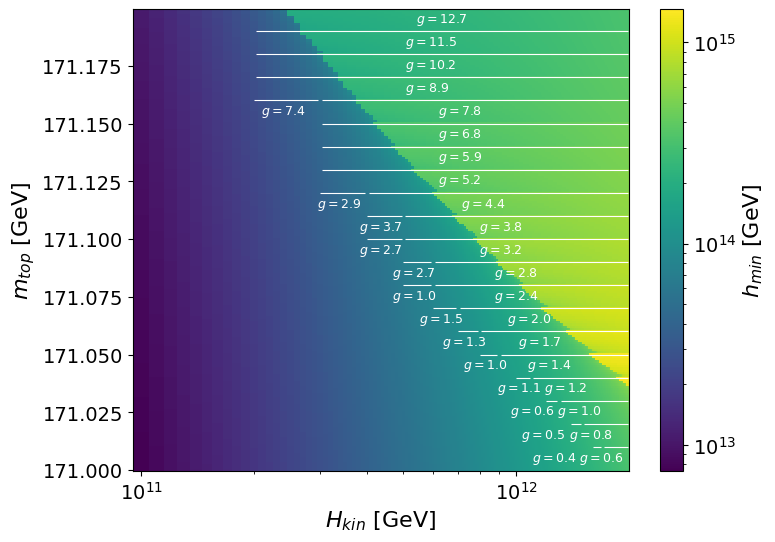

In [8]:
#Computing the field value at the minimum for points in (mtop,Hkin) plane and a matrix of values of g as input
nu=10
hoL = 1e17

#Values to compute hmin
mtops=np.arange(171,171.2,0.001)
Hkins=np.arange(1e11,2e12,1e10)

#Values where g is given
mtops_gs=np.arange(171,171.21,0.01)
Hkins_gs=np.arange(1e11,2.1e12,1e11)


g=0 
results = np.full((len(mtops), len(Hkins)), 1e-30)
gs = np.loadtxt("matrizgs.txt", delimiter="\t", dtype=float)

i_gs=0
j_gs=0

# End points for lines with g non zero
x_fin = [1.7e12, 1.5e12, 1.3e12, 1.1e12,9e11, 8e11, 7e11, 6e11,6e11, 5e11, 5e11, 4e11,3e11, 3e11, 3e11, 3e11, 2e11, 2e11,2e11]

# Values of g to print below long lines
g_vals = [0.6, 0.8, 1, 1.2,1.4, 1.7, 2, 2.4,2.8, 3.2, 3.8, 4.4,5.2, 5.9, 6.8, 7.8, 8.9,10.2,11.5]
# Values of g to print below short lines
g_vals2 = [0.4, 0.5, 0.6, 1.1,1, 1.3, 1.5, 1,2.7, 2.7, 3.7, 2.9,0, 0, 0, 7.4, 0,0,0]

for i, mtop in enumerate(mtops):
    for j, Hkin in enumerate(Hkins):
        Xi = 2.0 * nu**2 / 3.0
        fStar = np.sqrt(6.0 * Xi) * Hkin
        g=gs[i_gs,j_gs]
        
        zbr=27
        Ht=Hubble(Hkin,zbr,fStar)
        Vder = make_Vder(Hkin, Ht,nu, hoL, g, mtop)
        sols = find_roots(Vder,1e6,1e16)

        if len(sols)>0:
            ht=sols[0]
            results[i,j]= ht
        else:
            result=1e-30
            results[i, j] = result

        if abs(Hkin-Hkins_gs[j_gs])<1e8:
            j_gs=j_gs+1
        if abs(Hkin - Hkins[-1])<1e8:
            j_gs=0

    if abs(mtop -mtops_gs[i_gs])<1e-4:
        i_gs=i_gs+1
        

X, Y = np.meshgrid(Hkins, mtops)

plt.figure(figsize=(8,6))

pcm = plt.pcolormesh(X,Y,results,shading='auto',cmap='viridis',norm=LogNorm())
ax = plt.gca()

x_max = 1.99e12

for y, x_stop, g, g2 in zip(mtops_gs, x_fin, g_vals,g_vals2):

    #Drawing long lines
    ax.hlines(
        y=y+0.01,
        xmin=x_stop+1e-2*x_stop,
        xmax=x_max,
        colors='white',
        linewidth=0.8
    )

    #Text with the values of g
    x_text = 0.8*np.sqrt(x_stop * x_max)
    ax.text(
        x_text,
        y + 0.004,
        fr"$g={g:.1f}$",
        color='white',
        fontsize=9,
        ha='left'
    )

    #Short lines
    if g2!=0:
        ax.hlines(
            y=y+0.01,
            xmin=x_stop-1e11,
            xmax=x_stop-1e-2*x_stop,
            colors='white',
            linewidth=0.8
        )

        if g2==0.4:
            x_text2 = 0.85*np.sqrt(x_stop * (x_stop-1e11))-3e11
        else:
            if g2==0.5:
                x_text2 = 0.85*np.sqrt(x_stop * (x_stop-1e11))-2e11
            else: 
                if g2==0.6:
                    x_text2 = 0.85*np.sqrt(x_stop * (x_stop-1e11))-1e11
                else:
                    x_text2 = 0.85*np.sqrt(x_stop * (x_stop-1e11))
        ax.text(
            x_text2,
            y + 0.004,
            fr"$g={g2:.1f}$",
            color='white',
            fontsize=9,
            ha='left'
        )
#Last value of g without line
ax.text(
    np.sqrt(2e11*x_max),
    171.19 + 0.004,
    fr"$g=12.7$",
    color='white',
    fontsize=9,
    ha='center'
)

cbar=plt.colorbar(pcm)
cbar.set_label(r"$h_{min}$ [GeV]", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.xlabel(r"$H_{kin}$ [GeV]",fontsize=16)
plt.ylabel(r"$m_{top}$ [GeV]",fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xscale('log')
plt.savefig("escaneo_energias.svg")

plt.show()

# Minima/maxima

### $(m_{top},g)$ plane

In [ ]:
# Scan of the number of extrema
nu = 10
Hkin = 1e11
hoL = 1e17
hmin = 1e10
hmax = 1e17

#Grid
gmin=0
gmax=10
mtopmin=171.0
mtopmax=171.3
dg=0.01
dmtop=0.0002
g_values = np.arange(gmin, gmax, dg)
mtop_values = np.arange(mtopmin, mtopmax, dmtop)

#Points for computing back-reaction time
mtop_values_zbr = np.arange(mtopmin, mtopmax, 0.02)

Xi = nu*nu * 2 / 3
fStar = np.sqrt(6 * Xi) * Hkin

result = np.zeros((len(g_values), len(mtop_values)), dtype=int)

for j, mtop in enumerate(mtop_values):
    #Computing back-reaction time
    for l in mtop_values_zbr:
        if np.abs(mtop-l)<1e-5:
            z_br,Hbr,hbr = zbr_calculo(Hkin,nu,mtop)
    for i, g in enumerate(g_values):
        Hz = Hubble(Hkin,z_br,fStar)

        # Obtaining extrema
        Vder = make_Vder(Hkin, Hz,nu, hoL, g, mtop)
        sols = find_roots(Vder,hmin,hmax)

        n = len(sols)

        if n == 1:
            result[i, j] = 0 #One minimum

        elif n == 2:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)
            if(rho>f2):
                result[i, j] = 1 #One minimum and one maximum: barrier crossed
            else:
                result[i,j] = 2 #One minimum and one maximum: barrier not crossed

        elif n == 3:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            f3 = potential(sols[2],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)

            if f3>f1:
                if f3>0:
                    if rho>f2:
                        result[i,j]=3 #Two minima, second metastable and possitive and barrier crossed
                    else:
                        result[i,j]=4 #Two minima, second metastable and possitive and barrier not crossed
                else:
                    result[i,j]=5 #Two minima, second metastable and negative
            else:
                if rho>f2:
                    result[i,j]=6 #Two minima, second stable and barrier crossed
                else:
                    result[i,j]=7 #Two minima, second stable and barrier not crossed

        else:
            result[i, j] = 8 #No extrema
np.savetxt("result_gmtop.txt", result, fmt="%d")


Sign change found:
26.98674668667167 26.996749187296825
z_br   = 2.69893611e+01 H(zbr) = 1.98082397e+10 h(zbr) = 4.10317882e+12
Sign change found:
27.036759189797447 27.046761690422606
z_br   = 2.70374473e+01 H(zbr) = 1.97799790e+10 h(zbr) = 4.15800780e+12
Sign change found:
27.08677169292323 27.096774193548388
z_br   = 2.70869144e+01 H(zbr) = 1.97509907e+10 h(zbr) = 4.21523087e+12
Sign change found:
27.13678419604901 27.14678669667417
z_br   = 2.71378369e+01 H(zbr) = 1.97212382e+10 h(zbr) = 4.27502651e+12
Sign change found:
27.186796699174792 27.196799199799948
z_br   = 2.71902960e+01 H(zbr) = 1.96906815e+10 h(zbr) = 4.33759207e+12
Sign change found:
27.236809202300574 27.24681170292573
z_br   = 2.72443794e+01 H(zbr) = 1.96592775e+10 h(zbr) = 4.40314644e+12
Sign change found:
27.29682420605151 27.30682670667667
z_br   = 2.73001805e+01 H(zbr) = 1.96269811e+10 h(zbr) = 4.47193351e+12
Sign change found:
27.356839209802448 27.366841710427607
z_br   = 2.73578022e+01 H(zbr) = 1.95937420e+10

In [58]:
#Upload the previous data if it has already been saved
nu = 10
Hkin = 1e11
hoL = 1e17
hmin = 1e10
hmax = 1e17

gmin=0
gmax=10
mtopmin=171.0
mtopmax=171.3
dg=0.01
dmtop=0.0002

Xi = nu*nu * 2 / 3
fStar = np.sqrt(6 * Xi) * Hkin

g_values = np.arange(gmin, gmax, dg)
mtop_values = np.arange(mtopmin, mtopmax, dmtop)
mtop_values_zbr = np.arange(mtopmin, mtopmax, 0.1)
result = np.loadtxt("result_gmtop.txt")

In [59]:
# Zoom in a specific part of the scan plane
gmin_zoom=8
gmax_zoom=8.001
mtopmin_zoom=171.16424
mtopmax_zoom=171.16426
dg_zoom=0.000001
dmtop_zoom=0.0000001

Xi = nu*nu * 2 / 3
fStar = np.sqrt(6 * Xi) * Hkin

g_values_zoom = np.arange(gmin_zoom, gmax_zoom, dg_zoom)
mtop_values_zoom = np.arange(mtopmin_zoom, mtopmax_zoom, dmtop_zoom)
mtop_values_zbr_zoom = np.arange(mtopmin_zoom, mtopmax_zoom, 0.01)

result_zoom = np.zeros((len(g_values_zoom), len(mtop_values_zoom)), dtype=int)

for j, mtop in enumerate(mtop_values_zoom):
    for l in mtop_values_zbr_zoom:
        if np.abs(mtop-l)<1e-9:
            print(mtop,l)
            z_br,Hbr,hbr = zbr_calculo(Hkin,nu,mtop)
    for i, g in enumerate(g_values_zoom):
        Hz = Hubble(Hkin,z_br,fStar)

        Vder= make_Vder(Hkin, Hz,nu, hoL, g, mtop)

        sols = find_roots(Vder,hmin,hmax)

        n = len(sols)

        if n == 1:
            result_zoom[i, j] = 0 #One minimum

        elif n == 2:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)
            if(rho>f2):
                result_zoom[i, j] = 1 #One minimum and one maximum: barrier crossed
            else:
                result_zoom[i,j] = 2 #One minimum and one maximum: barrier not crossed

        elif n == 3:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            f3 = potential(sols[2],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Ht,nu,mtop)

            if f3>f1:
                if f3>0:
                    if rho>f2:
                        result_zoom[i,j]=3 #Two minima, second metastable and possitive and barrier crossed
                    else:
                        result_zoom[i,j]=4 #Two minima, second metastable and possitive and barrier not crossed
                else:
                    result_zoom[i,j]=5 #Two minima, second metastable and negative
            else:
                if rho>f2:
                    result_zoom[i,j]=6 #Two minima, second stable and barrier crossed
                else:
                    result_zoom[i,j]=7 #Two minima, second stable and barrier not crossed

        else:
            result_zoom[i, j] = 8 #No extrema


171.16424 171.16424
Sign change found:
27.426856714178545 27.4368592148037
z_br   = 2.74302373e+01 H(zbr) = 1.95521173e+10 h(zbr) = 4.63698134e+12


<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_64345/558844427.py:13: SyntaxWarning: invalid escape sequence '\l'
  labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]
/tmp/ipykernel_64345/558844427.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


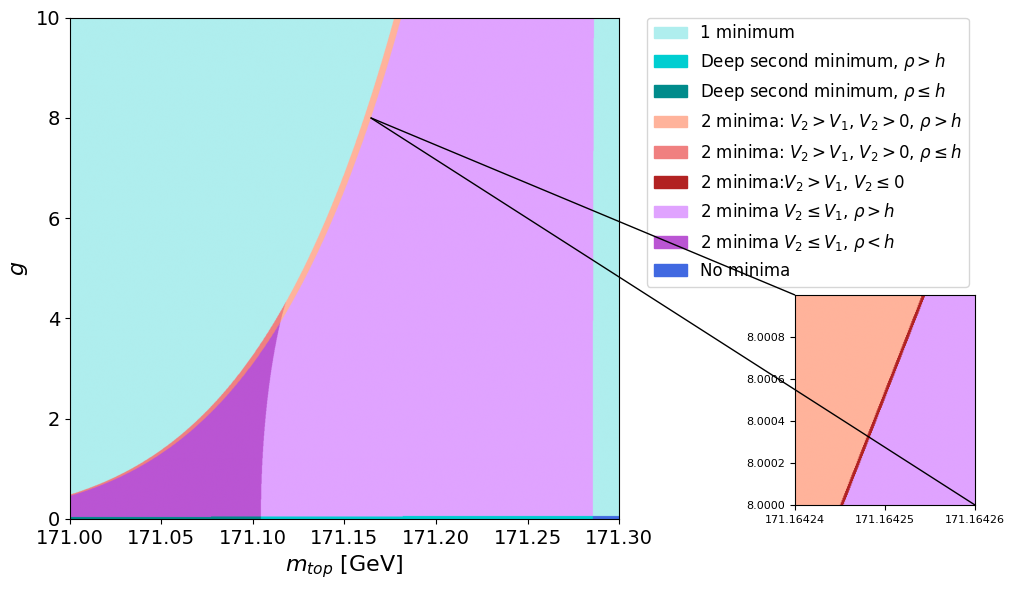

In [60]:
g_values = np.arange(gmin, gmax+dg, dg)
mtop_values = np.arange(mtopmin, mtopmax+dmtop, dmtop)

from matplotlib.colors import ListedColormap

cmap = ListedColormap(["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"])

fig, ax = plt.subplots(figsize=(10,6))

ax.imshow(result,origin="lower",aspect="auto",cmap=cmap,vmin=0,vmax=8,   extent=[mtop_values[0], mtop_values[-1], g_values[0], g_values[-1]])


labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]
colors = ["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"]


patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,fontsize=12)

ax.set_xlabel(r"$m_{top}$ [GeV]",fontsize=16)
ax.set_ylabel("$g$",fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)


axins = fig.add_axes([0.80, 0.15, 0.18, 0.35])

axins.imshow(result_zoom,origin="lower",aspect="auto",cmap=cmap,vmin=0,vmax=8,extent=[mtop_values_zoom[0],mtop_values_zoom[-1],g_values_zoom[0],g_values_zoom[-1]])

axins.set_xticks([171.16424, 171.16425, 171.16426]) 
axins.tick_params(labelsize=8)
axins.ticklabel_format(style='plain', useOffset=False)

mark_inset(ax,axins,loc1=2,loc2=4,fc="none",ec="black",lw=1)

plt.tight_layout()
plt.show()


### $(m_{top},H_{kin})$ plane

In [33]:
# Scan of the number of extrema
nu = 10
g = 1
hoL = 1e17
hmin = 1e10
hmax = 1e17

#Grid
Hkinmin=1e11
Hkinmax=1e12
mtopmin=171.0
mtopmax=171.2
dHkin=2e9
dmtop=0.0002
Hkin_values = np.arange(Hkinmin, Hkinmax, dHkin)
mtop_values = np.arange(mtopmin, mtopmax, dmtop)

Xi = nu*nu * 2 / 3

imax= len(Hkin_values)
jmax = len(mtop_values)
j_values_zbr = [0,jmax//4,2*jmax//4,3*jmax//4]
i_values_zbr = [0,imax//4,2*imax//4,3*jmax//4]


result2 = np.zeros((len(Hkin_values), len(mtop_values)), dtype=int)

for j, mtop in enumerate(mtop_values):
    for i, Hkin in enumerate(Hkin_values):
        fStar = np.sqrt(6 * Xi) * Hkin
            
        z_br=26
        Hz = Hubble(Hkin,z_br,fStar)

        Vder = make_Vder(Hkin, Ht,nu, hoL, g, mtop)

        sols = find_roots(Vder,hmin,hmax)

        n = len(sols)

        if n == 1:
            result2[i, j] = 0 #One minimum

        elif n == 2:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)
            if(rho>f2):
                result2[i, j] = 1 #One minimum and one maximum: barrier crossed
            else:
                result2[i,j] = 2 #One minimum and one maximum: barrier not crossed

        elif n == 3:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            f3 = potential(sols[2],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)
 
            if f3>f1:
                if f3>0:
                    if rho>f2:
                        result2[i,j]=3 #Two minima, second metastable and possitive and barrier crossed
                    else:
                        result2[i,j]=4 #Two minima, second metastable and possitive and barrier not crossed
                else:
                    result2[i,j]=5 #Two minima, second metastable and negative
            else:
                if rho>f2:
                    result2[i,j]=6 #Two minima, second stable and barrier crossed
                else:
                    result2[i,j]=7 #Two minima, second stable and barrier not crossed


        else:
            result2[i, j] = 8 #No extrema
np.savetxt("./result_Hkinmtop.txt", result2, fmt="%d")


In [61]:
#Upload the previous data if it has already been saved
nu = 10
g=1
hoL = 1e17
hmin = 1e10
hmax = 1e17

Hkinmin=1e11
Hkinmax=1e12
mtopmin=171.0
mtopmax=171.2
dHkin=2e9
dmtop=0.0002

Xi = nu*nu * 2 / 3
fStar = np.sqrt(6 * Xi) * Hkin

Hkin_values = np.arange(Hkinmin, Hkinmax, dHkin)
mtop_values = np.arange(mtopmin, mtopmax, dmtop)

result2 = np.loadtxt("./result_Hkinmtop.txt")

In [64]:
#Zoom in a specific part of the scan plane
Hkinmin_zoom=6e11
Hkinmax_zoom=6.001e11
mtopmin_zoom=171.03562
mtopmax_zoom=171.03566
dHkin_zoom=1e7
dmtop_zoom=0.00000001

Xi = nu*nu * 2 / 3
fStar = np.sqrt(6 * Xi) * Hkin

Hkin_values_zoom = np.arange(Hkinmin_zoom, Hkinmax_zoom, dHkin_zoom)
mtop_values_zoom = np.arange(mtopmin_zoom, mtopmax_zoom, dmtop_zoom)
mtop_values_zbr_zoom = np.arange(mtopmin_zoom, mtopmax_zoom, 0.01)
Hkin_values_zbr_zoom = np.arange(Hkinmin_zoom, Hkinmax_zoom, 1e11)

result2_zoom = np.zeros((len(Hkin_values_zoom), len(mtop_values_zoom)), dtype=int)

for i, Hkin in enumerate(Hkin_values_zoom):
    for j, mtop in enumerate(mtop_values_zoom):

        z_br=26
        Hz = Hubble(Hkin,z_br,fStar)

        Vder = make_Vder(Hkin, Hz,nu, hoL, g, mtop)

        sols = find_roots(Vder,hmin,hmax)

        n = len(sols)

        if n == 1:
            result2_zoom[i, j] = 0

        elif n == 2:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)
            if(rho>f2):
                result2_zoom[i, j] = 1
            else:
                result2_zoom[i,j] = 2

        elif n == 3:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            f3 = potential(sols[2],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)

            if f3>f1:
                if f3>0:
                    if rho>f2:
                        result2_zoom[i,j]=3
                    else:
                        result2_zoom[i,j]=4
                else:
                    result2_zoom[i,j]=5
            else:
                if rho>f2:
                    result2_zoom[i,j]=6
                else:
                    result2_zoom[i,j]=7

        else:
            result2_zoom[i, j] = 8


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_64345/1229649831.py:10: SyntaxWarning: invalid escape sequence '\l'
  labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]
/tmp/ipykernel_64345/1229649831.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


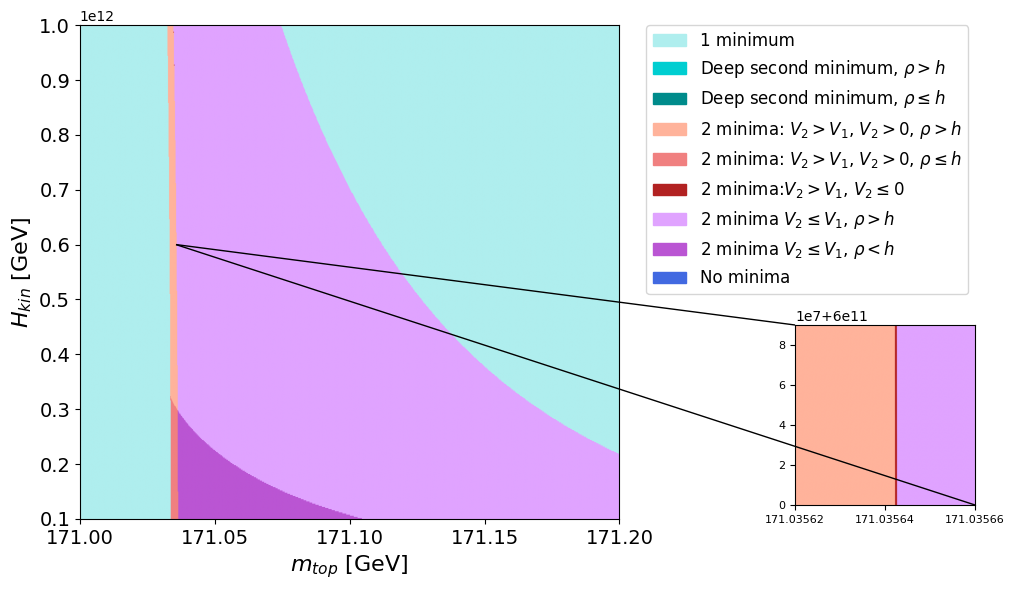

In [65]:
Hkin_values = np.arange(Hkinmin, Hkinmax+dHkin, dHkin)
mtop_values = np.arange(mtopmin, mtopmax+dmtop, dmtop)

cmap = ListedColormap(["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"])

fig, ax = plt.subplots(figsize=(10,6))

ax.imshow(result2,origin="lower",aspect="auto",cmap=cmap,vmin=0,vmax=8,   extent=[mtop_values[0], mtop_values[-1], Hkin_values[0], Hkin_values[-1]])

labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]
colors = ["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"]


patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,fontsize=12)


ax.set_xlabel(r"$m_{top}$ [GeV]",fontsize=16)
ax.set_ylabel(r"$H_{kin}$ [GeV]",fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.xaxis.set_major_locator(mticker.MaxNLocator(5))

axins = fig.add_axes([0.80, 0.15, 0.18, 0.3])

axins.imshow(result2_zoom,origin="lower",aspect="auto",cmap=cmap,vmin=0,vmax=8,extent=[mtop_values_zoom[0],mtop_values_zoom[-1],Hkin_values_zoom[0],Hkin_values_zoom[-1]])

axins.tick_params(labelsize=8)
axins.ticklabel_format(axis='x', style='plain', useOffset=False)
axins.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

axins.set_xticks([171.03562, 171.03564, 171.03566]) 

mark_inset(ax,axins,loc1=2,loc2=4,fc="none",ec="black",lw=1)

plt.tight_layout()
plt.show()


### ($\nu$,$m_{top}$) plane

In [10]:
# Scan of the number of extrema
g=1
Hkin = 1e11
hoL = 1e17
hmin = 1e10
hmax = 1e17

#Grid
numin=5
numax=35
mtopmin=171.0
mtopmax=171.3
dnu=0.1
dmtop=0.0002
nu_values = np.arange(numin, numax, dnu)
mtop_values = np.arange(mtopmin, mtopmax, dmtop)

result3 = np.zeros((len(nu_values), len(mtop_values)), dtype=int)

for j, mtop in enumerate(mtop_values):
    for i, nu in enumerate(nu_values):
        Xi = nu*nu * 2 / 3
        fStar = np.sqrt(6 * Xi) * Hkin
        
        z_br = 26
        Hz = Hubble(Hkin,z_br,fStar)

        # Obtaining extrema
        Vder = make_Vder(Hkin, Hz,nu, hoL, g, mtop)
        sols = find_roots(Vder,hmin,hmax)

        n = len(sols)

        if n == 1:
            result3[i, j] = 0 #One minimum

        elif n == 2:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)
            if(rho>f2):
                result3[i, j] = 1 #One minimum and one maximum: barrier crossed
            else:
                result3[i,j] = 2 #One minimum and one maximum: barrier not crossed

        elif n == 3:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            f3 = potential(sols[2],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)

            if f3>f1:
                if f3>0:
                    if rho>f2:
                        result3[i,j]=3 #Two minima, second metastable and possitive and barrier crossed
                    else:
                        result3[i,j]=4 #Two minima, second metastable and possitive and barrier not crossed
                else:
                    result3[i,j]=5 #Two minima, second metastable and negative
            else:
                if rho>f2:
                    result3[i,j]=6 #Two minima, second stable and barrier crossed
                else:
                    result3[i,j]=7 #Two minima, second stable and barrier not crossed

        else:
            result3[i, j] = 8 #No extrema
np.savetxt("result_numtop.txt", result3, fmt="%d")


<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_78016/3841085545.py:13: SyntaxWarning: invalid escape sequence '\l'
  labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]


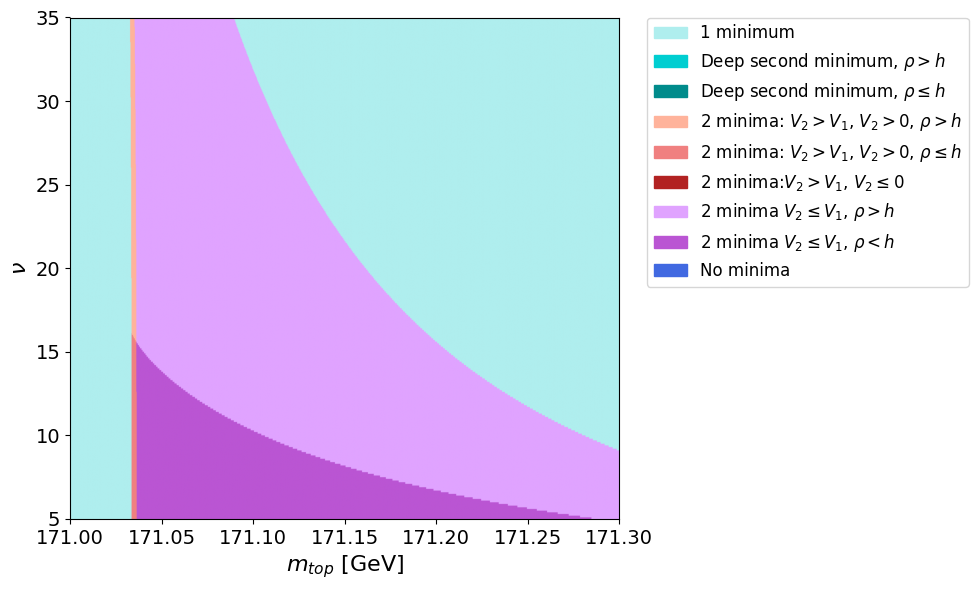

In [14]:
nu_values = np.arange(numin, numax+dnu, dnu)
mtop_values = np.arange(mtopmin, mtopmax+dmtop, dmtop)

from matplotlib.colors import ListedColormap

cmap = ListedColormap(["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"])

fig, ax = plt.subplots(figsize=(10,6))

ax.imshow(result3,origin="lower",aspect="auto",cmap=cmap,vmin=0,vmax=8,   extent=[mtop_values[0], mtop_values[-1], nu_values[0], nu_values[-1]])


labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]
colors = ["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"]


patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,fontsize=12)

ax.set_xlabel(r"$m_{top}$ [GeV]",fontsize=16)
ax.set_ylabel(r"$\nu$",fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig("./graficas_finales/numtop.svg")
plt.show()


### ($g$,$H_{kin}$) plane

In [18]:
# Scan of the number of extrema
mtop=171.1
nu=10
hoL = 1e17
hmin = 1e10
hmax = 1e17

#Grid
gmin=0
gmax=5
Hkinmin=1e11
Hkinmax=1e12
dg=0.01
dHkin=1e9
g_values = np.arange(gmin, gmax, dg)
Hkin_values = np.arange(Hkinmin, Hkinmax, dHkin)

result4 = np.zeros((len(g_values), len(Hkin_values)), dtype=int)

for j, Hkin in enumerate(Hkin_values):
    for i, g in enumerate(g_values):
        Xi = nu*nu * 2 / 3
        fStar = np.sqrt(6 * Xi) * Hkin
        
        z_br = 26
        Hz = Hubble(Hkin,z_br,fStar)

        # Obtaining extrema
        Vder = make_Vder(Hkin, Hz,nu, hoL, g, mtop)
        sols = find_roots(Vder,hmin,hmax)

        n = len(sols)

        if n == 1:
            result4[i, j] = 0 #One minimum

        elif n == 2:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)
            if(rho>f2):
                result4[i, j] = 1 #One minimum and one maximum: barrier crossed
            else:
                result4[i,j] = 2 #One minimum and one maximum: barrier not crossed

        elif n == 3:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            f3 = potential(sols[2],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)

            if f3>f1:
                if f3>0:
                    if rho>f2:
                        result4[i,j]=3 #Two minima, second metastable and possitive and barrier crossed
                    else:
                        result4[i,j]=4 #Two minima, second metastable and possitive and barrier not crossed
                else:
                    result4[i,j]=5 #Two minima, second metastable and negative
            else:
                if rho>f2:
                    result4[i,j]=6 #Two minima, second stable and barrier crossed
                else:
                    result4[i,j]=7 #Two minima, second stable and barrier not crossed

        else:
            result4[i, j] = 8 #No extrema
np.savetxt("result_gHkin.txt", result4, fmt="%d")

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_78016/3163870090.py:13: SyntaxWarning: invalid escape sequence '\l'
  labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]


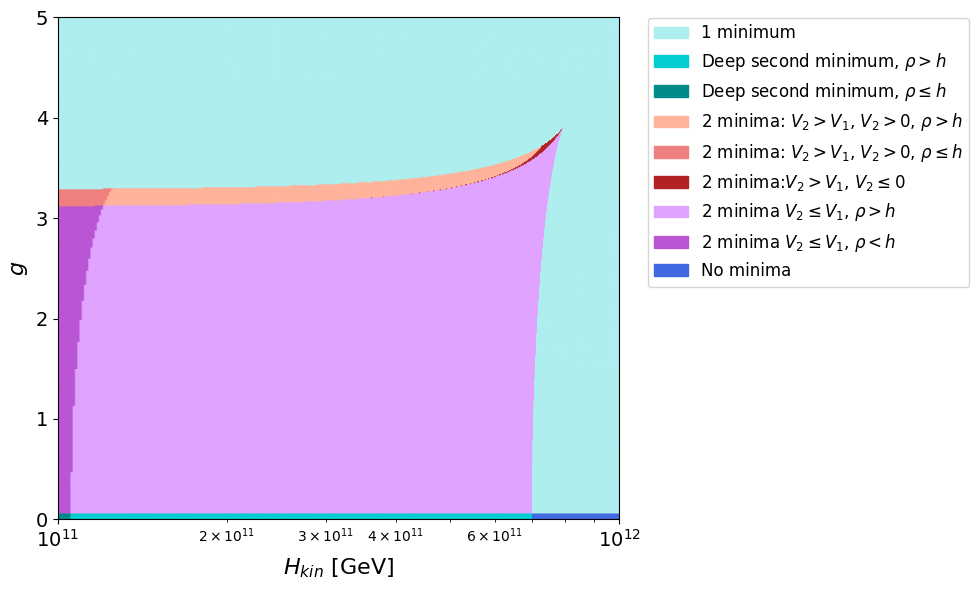

In [19]:
g_values = np.arange(gmin, gmax+dg, dg)
Hkin_values = np.arange(Hkinmin, Hkinmax+dHkin, dHkin)

from matplotlib.colors import ListedColormap

cmap = ListedColormap(["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"])

fig, ax = plt.subplots(figsize=(10,6))

ax.imshow(result4,origin="lower",aspect="auto",cmap=cmap,vmin=0,vmax=8,   extent=[Hkin_values[0], Hkin_values[-1], g_values[0], g_values[-1]])


labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]
colors = ["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"]


patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,fontsize=12)

ax.set_xlabel(r"$H_{kin}$ [GeV]",fontsize=16)
ax.set_ylabel(r"$g$",fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xscale('log')

plt.tight_layout()
plt.savefig("./graficas_finales/gHkin.svg")
plt.show()


### $(\nu,H_{kin})$ plane

In [27]:
# Scan of the number of extrema
mtop=171.1
g=1
hoL = 1e17
hmin = 1e10
hmax = 1e17

#Grid
numin=5
numax=35
Hkinmin=1.5e10
Hkinmax=1e12
dnu=0.1
dHkin=1e9
nu_values = np.arange(numin, numax, dnu)
Hkin_values = np.arange(Hkinmin, Hkinmax, dHkin)

result5 = np.zeros((len(nu_values), len(Hkin_values)), dtype=int)

for j, Hkin in enumerate(Hkin_values):
    for i, nu in enumerate(nu_values):
        Xi = nu*nu * 2 / 3
        fStar = np.sqrt(6 * Xi) * Hkin
        
        z_br = 26
        Hz = Hubble(Hkin,z_br,fStar)

        # Obtaining extrema
        Vder = make_Vder(Hkin, Hz,nu, hoL, g, mtop)
        sols = find_roots(Vder,hmin,hmax)

        n = len(sols)

        if n == 1:
            result5[i, j] = 0 #One minimum

        elif n == 2:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)
            if(rho>f2):
                result5[i, j] = 1 #One minimum and one maximum: barrier crossed
            else:
                result5[i,j] = 2 #One minimum and one maximum: barrier not crossed

        elif n == 3:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            f3 = potential(sols[2],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)

            if f3>f1:
                if f3>0:
                    if rho>f2:
                        result5[i,j]=3 #Two minima, second metastable and possitive and barrier crossed
                    else:
                        result5[i,j]=4 #Two minima, second metastable and possitive and barrier not crossed
                else:
                    result5[i,j]=5 #Two minima, second metastable and negative
            else:
                if rho>f2:
                    result5[i,j]=6 #Two minima, second stable and barrier crossed
                else:
                    result5[i,j]=7 #Two minima, second stable and barrier not crossed

        else:
            result5[i, j] = 8 #No extrema
np.savetxt("result_nuHkin.txt", result5, fmt="%d")

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_78016/670700222.py:13: SyntaxWarning: invalid escape sequence '\l'
  labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]


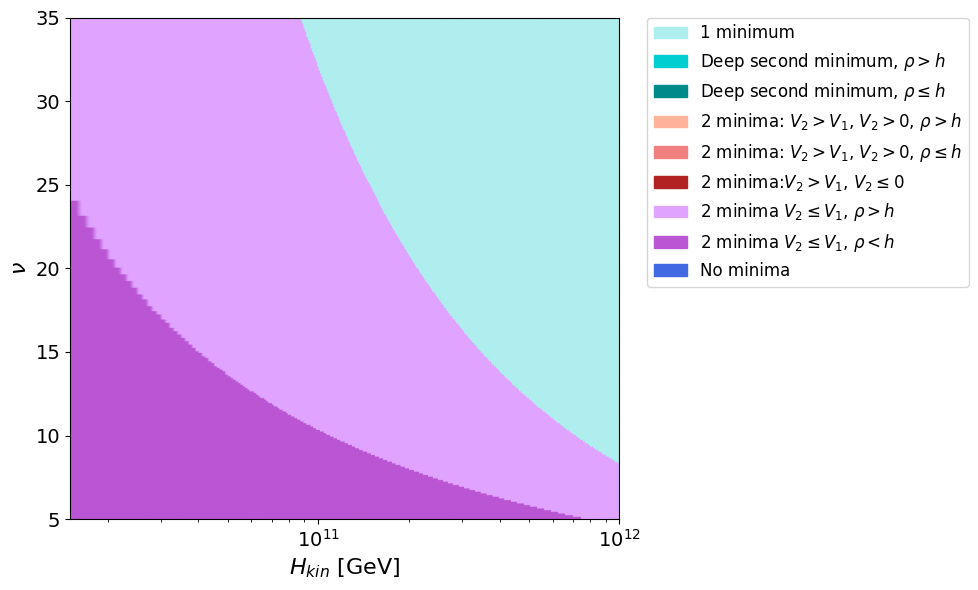

In [28]:
nu_values = np.arange(numin, numax+dnu, dnu)
Hkin_values = np.arange(Hkinmin, Hkinmax+dHkin, dHkin)

from matplotlib.colors import ListedColormap

cmap = ListedColormap(["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"])

fig, ax = plt.subplots(figsize=(10,6))

ax.imshow(result5,origin="lower",aspect="auto",cmap=cmap,vmin=0,vmax=8,   extent=[Hkin_values[0], Hkin_values[-1], nu_values[0], nu_values[-1]])


labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]
colors = ["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"]


patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,fontsize=12)

ax.set_xlabel(r"$H_{kin}$ [GeV]",fontsize=16)
ax.set_ylabel(r"$\nu$",fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_xscale('log')

plt.tight_layout()
plt.savefig("./graficas_finales/nuHkin.svg")
plt.show()

## ($\nu,g$) plane

In [35]:
# Scan of the number of extrema
mtop=171.1
Hkin=1e11
hoL = 1e17
hmin = 1e10
hmax = 1e17

#Grid
numin=5
numax=35
gmin=0
gmax=5
dnu=0.1
dg=0.01
nu_values = np.arange(numin, numax, dnu)
g_values = np.arange(gmin, gmax, dg)

result6 = np.zeros((len(nu_values), len(g_values)), dtype=int)

for j, g in enumerate(g_values):
    for i, nu in enumerate(nu_values):
        Xi = nu*nu * 2 / 3
        fStar = np.sqrt(6 * Xi) * Hkin
        
        z_br = 26
        Hz = Hubble(Hkin,z_br,fStar)

        # Obtaining extrema
        Vder = make_Vder(Hkin, Hz,nu, hoL, g, mtop)
        sols = find_roots(Vder,hmin,hmax)

        n = len(sols)

        if n == 1:
            result6[i, j] = 0 #One minimum

        elif n == 2:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)
            if(rho>f2):
                result6[i, j] = 1 #One minimum and one maximum: barrier crossed
            else:
                result6[i,j] = 2 #One minimum and one maximum: barrier not crossed

        elif n == 3:
            f1 = potential(sols[0],Hkin,Hz, nu, hoL, g, mtop)
            f2 = potential(sols[1],Hkin,Hz, nu, hoL, g, mtop)
            f3 = potential(sols[2],Hkin,Hz, nu, hoL, g, mtop)
            rho= energy_br_fit(sols[0],Hkin,Hz,nu,mtop)

            if f3>f1:
                if f3>0:
                    if rho>f2:
                        result6[i,j]=3 #Two minima, second metastable and possitive and barrier crossed
                    else:
                        result6[i,j]=4 #Two minima, second metastable and possitive and barrier not crossed
                else:
                    result6[i,j]=5 #Two minima, second metastable and negative
            else:
                if rho>f2:
                    result6[i,j]=6 #Two minima, second stable and barrier crossed
                else:
                    result6[i,j]=7 #Two minima, second stable and barrier not crossed

        else:
            result6[i, j] = 8 #No extrema
np.savetxt("result_nug.txt", result6, fmt="%d")

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_78016/1237956939.py:13: SyntaxWarning: invalid escape sequence '\l'
  labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]


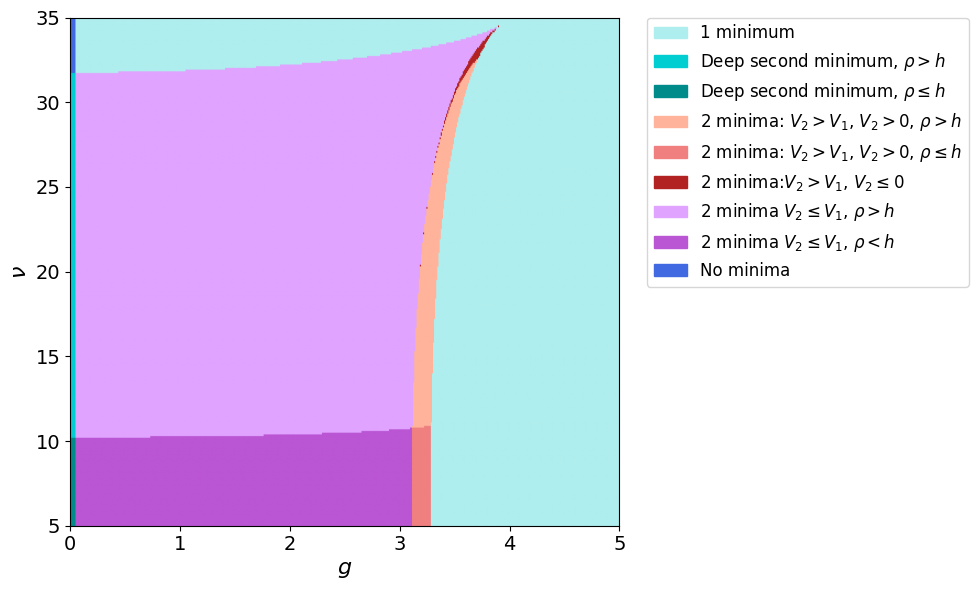

In [36]:
nu_values = np.arange(numin, numax+dnu, dnu)
g_values = np.arange(gmin, gmax+dg, dg)

from matplotlib.colors import ListedColormap

cmap = ListedColormap(["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"])

fig, ax = plt.subplots(figsize=(10,6))

ax.imshow(result6,origin="lower",aspect="auto",cmap=cmap,vmin=0,vmax=8,   extent=[g_values[0], g_values[-1], nu_values[0], nu_values[-1]])


labels = ["1 minimum", r"Deep second minimum, $\rho>h$", r"Deep second minimum, $\rho\leq h$", r"2 minima: $V_2>V_1$, $V_2>0$, $\rho>h$",r"2 minima: $V_2>V_1$, $V_2>0$, $\rho\leq h$","2 minima:$V_2>V_1$, $V_2\leq 0$", r"2 minima $V_2\leq V_1$, $\rho>h$",r"2 minima $V_2\leq V_1$, $\rho<h$", "No minima"]
colors = ["paleturquoise", "darkturquoise", "darkcyan", "#FFB39B","lightcoral", "firebrick", "#E0A3FF","mediumorchid","royalblue"]


patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(len(labels))]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,fontsize=12)

ax.set_xlabel(r"$g$",fontsize=16)
ax.set_ylabel(r"$\nu$",fontsize=16)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.savefig("./graficas_finales/nug.svg")
plt.show()